In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Stochastic Gradient Descent

Stochastic gradient descent has trained every model in this book so far,
without our ever justifying it. that section supplied the descent half of
the story; this section supplies the stochastic half: what replacing the
gradient by a noisy estimate does to the trajectory, why the learning rate
must then decay, and how the minibatch size controls the noise.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
from jax import numpy as jnp
import math

## Stochastic Gradient Updates

In deep learning, the objective function is an average of per-example losses.
Given a training dataset of $n$ examples with loss $f_i(\mathbf{x})$ on the
example of index $i$, where $\mathbf{x}$ is the parameter vector, the
objective is

$$f(\mathbf{x}) = \frac{1}{n} \sum_{i = 1}^n f_i(\mathbf{x}),$$

with gradient

$$\nabla f(\mathbf{x}) = \frac{1}{n} \sum_{i = 1}^n \nabla f_i(\mathbf{x}).$$

Gradient descent therefore pays $\mathcal{O}(n)$ per update — a full pass
over the dataset to move the parameters once. Stochastic gradient descent
(SGD) refuses to pay it. At each iteration it samples an index
$i\in\{1,\ldots, n\}$ uniformly at random and updates using that single
example's gradient:

$$\mathbf{x} \leftarrow \mathbf{x} - \eta \nabla f_i(\mathbf{x}),$$

where $\eta$ is the learning rate. The cost per iteration drops from
$\mathcal{O}(n)$ to $\mathcal{O}(1)$, and the estimate is *unbiased*: because
$i$ is uniform,

$$\mathbb{E}_i \nabla f_i(\mathbf{x}) = \frac{1}{n} \sum_{i = 1}^n \nabla f_i(\mathbf{x}) = \nabla f(\mathbf{x}).$$

On average the stochastic gradient points the right way; any single draw may
point almost anywhere. To see what that does to the trajectory we revisit the
quadratic $f(x_1, x_2) = x_1^2 + 2x_2^2$ from that section and simulate
the sampling noise by adding zero-mean, unit-variance Gaussian noise to each
gradient evaluation (the exercises show this simulation is faithful to
sampling from an actual dataset).

In [2]:
def f(x1, x2):  # Objective function
    return x1 ** 2 + 2 * x2 ** 2

def f_grad(x1, x2):  # Gradient of the objective function
    return 2 * x1, 4 * x2

In [3]:
def sgd(x1, x2, s1, s2, f_grad):
    global key
    g1, g2 = f_grad(x1, x2)
    # Simulate noisy gradient: split off a fresh subkey per step, the JAX
    # idiom for drawing a stream of random numbers
    key, subkey = jax.random.split(key)
    n1, n2 = jax.random.normal(subkey, (2,))
    eta_t = eta * lr()
    return (x1 - eta_t * (g1 + n1), x2 - eta_t * (g2 + n2), 0, 0)

key = jax.random.PRNGKey(42)

epoch 50, x1: -0.141533, x2: -0.069805


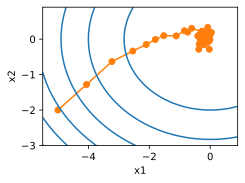

In [4]:
def constant_lr():
    return 1

eta = 0.1
lr = constant_lr  # Constant learning rate
d2l.show_trace_2d(f, d2l.train_2d(sgd, steps=50, f_grad=f_grad))

The trajectory is far noisier than the gradient-descent trace in
that section, and, more troubling, it does not settle: run it for more
steps and the quality stops improving (we encourage you to check). The reason
is visible in the update rule. Near the minimum the true gradient vanishes,
but the noise does not, so each step still moves the parameters by $\eta$
times pure noise. With a constant learning rate the iterates end up executing
a random walk around the optimum instead of converging to it. Shrinking
$\eta$ tames the walk but slows the approach; the way out of this bind is to
change $\eta$ *during* optimization, which is why the step function above
threads through a learning rate function `lr`, dormant so far.

## Dynamic Learning Rate

How close does that random walk get? For a quadratic bowl the answer is
sharp enough to guide practice. Model one coordinate of the update as
$x_{t+1} = x_t - \eta\, (\lambda x_t + \xi_t)$, with curvature $\lambda$ and
zero-mean noise $\xi_t$ of variance $\sigma^2$. Far from the optimum the
contraction term dominates and SGD makes gradient-descent-like progress.
Close to it, contraction and noise injection balance at

$$\mathbb{E}\big[x_\infty^2\big] \approx \frac{\eta\, \sigma^2}{2\lambda}.$$

The iterates rattle around inside a *noise ball* whose squared radius grows
linearly with the learning rate — the same noise ball that
that section promised an explanation for when it first
named the phenomenon; the two-line derivation, and a picture of
GD and SGD racing on the same bowl, are in
that section. Equation the equation
says exactly what the demo showed: a constant $\eta$ stalls at a noise floor
proportional to $\eta$. Halving $\eta$ halves the floor — and also halves the
speed of the initial approach. The escape is a *time-dependent* learning rate
$\eta(t)$: large early to cross the valley, decaying later to quench the
noise.

Choosing how fast $\eta(t)$ decays becomes the new problem. Too fast, and
optimization stops prematurely; too slow, and we waste time bouncing in the
ball. A few basic strategies (more refined ones follow in
that section):

$$
\begin{aligned}
    \eta(t) & = \eta_i \textrm{ if } t_i \leq t \leq t_{i+1}  && \textrm{piecewise constant} \\
    \eta(t) & = \eta_0 \cdot e^{-\lambda t} && \textrm{exponential decay} \\
    \eta(t) & = \eta_0 \cdot (\beta t + 1)^{-\alpha} && \textrm{polynomial decay}
\end{aligned}
$$

In the *piecewise constant* scenario we drop the learning rate whenever
progress stalls — riding each noise floor until we hit it, then lowering the
floor. *Exponential decay* is more aggressive. *Polynomial decay* with
$\alpha = 0.5$ is a standard well-behaved choice for convex problems. Let's
see what exponential decay looks like in practice.

epoch 1000, x1: -0.810909, x2: -0.028332


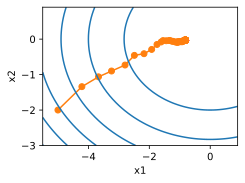

In [5]:
def exponential_lr():
    # Global variable that is defined outside this function and updated inside
    global t
    t += 1
    return math.exp(-0.1 * t)

t = 1
lr = exponential_lr
d2l.show_trace_2d(f, d2l.train_2d(sgd, steps=1000, f_grad=f_grad))

The variance in the parameters is much reduced — but the iterates never reach
the optimum $\mathbf{x} = (0, 0)$, even after 1000 steps. The schedule
quenches the noise *too* eagerly: its total budget $\sum_t \eta(t)$ is
finite, so the iterate can only ever travel a bounded distance from where it
started. It stops not because it has arrived but because it has run out of
learning rate. Polynomial decay with $\alpha = 0.5$ avoids that trap, and
convergence improves after only 50 steps.

epoch 50, x1: 0.037837, x2: 0.002780


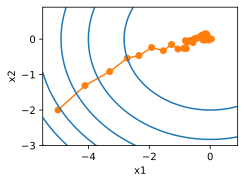

In [6]:
def polynomial_lr():
    # Global variable that is defined outside this function and updated inside
    global t
    t += 1
    return (1 + 0.1 * t) ** (-0.5)

t = 1
lr = polynomial_lr
d2l.show_trace_2d(f, d2l.train_2d(sgd, steps=50, f_grad=f_grad))

The two experiments are instances of a classical theorem.
@Robbins.Monro.1951 — the paper that founded stochastic
approximation — showed that convergence requires exactly the two properties
the demos probe: the learning rates must sum to infinity,
$\sum_t \eta(t) = \infty$, so the iterate can travel arbitrarily far (the
condition exponential decay just violated), while their squares must remain
controlled, $\sum_t \eta(t)^2 < \infty$, so the injected noise is eventually
quenched. Polynomial decay with $\alpha \in (1/2, 1]$ satisfies both; our
$\alpha = 1/2$ sits at the edge of the window, where running for a fixed
budget of $T$ steps with averaged iterates gives the classical
$\mathcal{O}(1/\sqrt{T})$ guarantee for convex objectives. We state these
results rather than prove them: the convex rates, and the traps hidden in
their constants, are worked out in
that section. None of the noise-ball reasoning
needs convexity, either — for smooth nonconvex objectives SGD still drives
the expected gradient norm to zero at a noise-controlled rate, the theorem of
@Ghadimi.Lan.2013 proved in that section.

## Gradient Variance and Batch Size

So far the noise was ours: we chose $\sigma = 1$. In real training the noise
comes from *which* examples land in the minibatch, and there we hold a dial —
the batch size $b$. A minibatch gradient averages $b$ independent draws, so
its variance is $1/b$ times the single-example variance
(that section states and proves this precisely).
That $1/b$ is a claim about real networks, so let us measure it on one: a
small two-layer MLP on the airfoil-noise regression dataset that serves as
this chapter's workhorse from that section on. We freeze the
parameters at a random initialization, take the full-dataset gradient as
ground truth, and measure the mean squared deviation of minibatch gradients
from it, for batch sizes spanning nearly three orders of magnitude —
sampling with replacement, matching the theory.

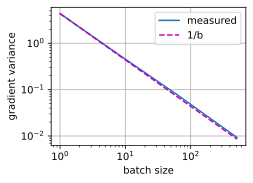

In [7]:
data_iter, feature_dim = d2l.get_data_ch11(batch_size=10)
X = jnp.concatenate([jnp.asarray(Xb) for Xb, yb in data_iter])
y = jnp.concatenate([jnp.asarray(yb) for Xb, yb in data_iter])

k1, k2 = jax.random.split(jax.random.PRNGKey(1))
params = dict(W1=0.1 * jax.random.normal(k1, (feature_dim, 64)),
              b1=jnp.zeros(64),
              W2=0.1 * jax.random.normal(k2, (64, 1)), b2=jnp.zeros(1))

def batch_loss(params, idx):
    h = jax.nn.relu(X[idx] @ params['W1'] + params['b1'])
    return jnp.mean(((h @ params['W2'] + params['b2']).squeeze()
                     - y[idx]) ** 2) / 2

def batch_grad(idx):  # Flattened loss gradient on the minibatch X[idx]
    grads = jax.grad(batch_loss)(params, idx)
    return jnp.concatenate([g.reshape(-1) for g in jax.tree.leaves(grads)])

g_full = batch_grad(jnp.arange(len(y)))
batch_sizes = [1, 8, 64, 512]
var, key = [], jax.random.PRNGKey(0)
for b in batch_sizes:
    key, subkey = jax.random.split(key)
    idx = jax.random.randint(subkey, (200, b), 0, len(y))
    err = jax.vmap(lambda i: ((batch_grad(i) - g_full) ** 2).sum())(idx)
    var.append(float(err.mean()))
d2l.plot(batch_sizes, [var, [var[0] / b for b in batch_sizes]],
         'batch size', 'gradient variance', xscale='log', yscale='log',
         legend=['measured', '1/b'])

The measured points fall on the $1/b$ reference line across the whole range:
a factor of 500 in batch size buys a factor of 500 in variance. Note what
the log scale conceals. Variance falling like $1/b$ means
noise *amplitude* falls like $1/\sqrt{b}$, so spending $100\times$ more
compute per step buys only a $10\times$ quieter gradient. Batch size is thus
a genuine second dial next to the learning rate, but one with diminishing
returns. How to spend a compute budget between the two —
and how batching interacts with the hardware that made it cheap — is the
subject of that section; what happens to the $1/b$ payoff at
the scale of modern language models is taken up in that section.

One loose end. Our theory, and the measurement above, sampled indices *with
replacement*: each draw is independent, which is what makes the analysis
clean. Practice does something else. Drawing $n$ times with replacement
touches only a fraction $1 - (1-1/n)^n \approx 1 - e^{-1} \approx 0.63$ of
the dataset per pass while picking other examples twice or more — worse data
efficiency, and higher variance, than simply shuffling the dataset and
traversing it exactly once per epoch. So that is what every training loop in
this book does, reshuffling before each epoch. The cost is theoretical:
within an epoch, successive gradients are no longer independent, and the
clean proofs no longer apply verbatim. The gap is real but benign in
practice, and the exercises take it up.

## Summary

SGD trades exactness for speed: an unbiased $\mathcal{O}(1)$-per-step
gradient estimate in place of an $\mathcal{O}(n)$ exact one. The price is
variance, and this section met both of the dials that control it. A constant
learning rate leaves the iterates rattling in a noise ball of squared radius
proportional to $\eta$; decaying learning rates converge, provided the decay
is slow enough to travel arbitrarily far yet fast enough to quench the noise.
Batch size is the other dial: minibatch gradient variance falls like $1/b$,
measured on a real network over a factor of 500 in batch size, though at a
linear cost in compute per step. The proofs owed here — the convex rates
and the nonconvex Ghadimi–Lan theorem — live in
that section and
that section.

## Exercises

1. Experiment with different learning rate schedules for stochastic gradient descent and with different numbers of iterations. In particular, plot the distance from the optimal solution $(0, 0)$ as a function of the number of iterations.
1. Prove that for the function $f(x_1, x_2) = x_1^2 + 2 x_2^2$ adding normal noise to the gradient is equivalent to minimizing a loss function $f(\mathbf{x}, \mathbf{w}) = (x_1 - w_1)^2 + 2 (x_2 - w_2)^2$ where $\mathbf{x}$ is drawn from a normal distribution.
1. Compare convergence of stochastic gradient descent when you sample from $\{(x_1, y_1), \ldots, (x_n, y_n)\}$ with replacement and when you sample without replacement.
1. How would you change the stochastic gradient descent solver if some gradient (or rather some coordinate associated with it) was consistently larger than all the other gradients?
1. Assume that $f(x) = x^2 (1 + \sin x)$. How many local minima does $f$ have? Can you change $f$ in such a way that to minimize it one needs to evaluate all the local minima?
1. Repeat the gradient-variance measurement of this section at the parameters reached *after* training the network (use any optimizer from this chapter). Does the $1/b$ dependence still hold? What changes — the slope or the level — and why?

[Discussions](https://d2l.discourse.group/t/1067)